In [9]:
import glob
import json
import math
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# loading and inspecting dataset
CIC-IDS2017 Dataset contains multiple files of network traffic analysis encompasing different days of the week and different types of attacks

In [10]:
dataset_folder = '../dataset'
csv_files = glob.glob(os.path.join(dataset_folder, '*.csv'))
csv_files

['../dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 '../dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 '../dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv',
 '../dataset\\Monday-WorkingHours.pcap_ISCX.csv',
 '../dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 '../dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 '../dataset\\Tuesday-WorkingHours.pcap_ISCX.csv',
 '../dataset\\Wednesday-workingHours.pcap_ISCX.csv']

In [11]:
if 'dataset.parquet' in os.listdir(dataset_folder):
    df = pd.read_parquet(os.path.join(dataset_folder, 'dataset.parquet'))
else:
    df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)
    df.to_parquet(os.path.join(dataset_folder, 'dataset.parquet'), index=False)
    df = pd.read_parquet(os.path.join(dataset_folder, 'dataset.parquet'))

In [12]:
# Due to the large size of the dataset, we will work with a random sample of 30% of the data for EDA and model development.
df = df.sample(frac=0.3, random_state=42).reset_index(drop=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 849223 entries, 0 to 849222
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             849223 non-null  int64  
 1    Flow Duration                849223 non-null  int64  
 2    Total Fwd Packets            849223 non-null  int64  
 3    Total Backward Packets       849223 non-null  int64  
 4   Total Length of Fwd Packets   849223 non-null  int64  
 5    Total Length of Bwd Packets  849223 non-null  int64  
 6    Fwd Packet Length Max        849223 non-null  int64  
 7    Fwd Packet Length Min        849223 non-null  int64  
 8    Fwd Packet Length Mean       849223 non-null  float64
 9    Fwd Packet Length Std        849223 non-null  float64
 10  Bwd Packet Length Max         849223 non-null  int64  
 11   Bwd Packet Length Min        849223 non-null  int64  
 12   Bwd Packet Length Mean       849223 non-nul

In [14]:
df[' Label'].value_counts()

 Label
BENIGN                        681572
DoS Hulk                       69516
PortScan                       47894
DDoS                           38301
DoS GoldenEye                   3099
FTP-Patator                     2422
SSH-Patator                     1762
DoS slowloris                   1761
DoS Slowhttptest                1621
Bot                              600
Web Attack � Brute Force         472
Web Attack � XSS                 184
Web Attack � Sql Injection         9
Infiltration                       8
Heartbleed                         2
Name: count, dtype: int64

## checking out na and inf values

In [15]:
print('Number of missing values in each column:')
print(df.isna().sum()[df.isna().sum() > 0])
print('percent of missing values in each column:')
print((df.isna().sum()[df.isna().sum() > 0]) / len(df) * 100)

print('\nNumber of +infinite values in each column:')
print((df == np.inf).sum()[ (df == np.inf).sum() > 0 ])

print('\npercent of +infinite values in each column:')
print(((df == np.inf).sum()[ (df == np.inf).sum() > 0 ]) / len(df) * 100)


print('\nNumber of -infinite values in each column:')
print((df == -np.inf).sum()[ (df == -np.inf).sum() > 0 ])

print('\npercent of -infinite values in each column:')
print(((df == -np.inf).sum()[ (df == -np.inf).sum() > 0 ]) / len(df) * 100)

Number of missing values in each column:
Flow Bytes/s    414
dtype: int64
percent of missing values in each column:
Flow Bytes/s    0.04875
dtype: float64

Number of +infinite values in each column:
Flow Bytes/s       454
 Flow Packets/s    868
dtype: int64

percent of +infinite values in each column:
Flow Bytes/s       0.053461
 Flow Packets/s    0.102211
dtype: float64

Number of -infinite values in each column:
Series([], dtype: int64)

percent of -infinite values in each column:
Series([], dtype: float64)


# Preprocessing

In [16]:
# Prepare list for columns to drop
columns_to_drop = []

## Fix column names

In [17]:
# Removal of leading/trailing whitespace
original_features = {col: col.strip() for col in df.columns}
df = df.rename(columns = original_features)
df.columns

original_features = list(original_features.values())

# save original features as config file for later use
with open('..\config\preprocessing_df_config.json', 'w') as f:
    json.dump({"original_features": original_features}, f, indent=4)

## Remove duplicates
Removing duplicates is actually good as it removes redundancy with our model training, increasing efficiency and flattening out instance distribution

### row-wise

In [18]:
# Checking and counting duplicates
duplicates = df.duplicated()
duplicate_count = duplicates.sum()

# Output results
print(f"Number of duplicate rows: {duplicate_count}")

# Removal of duplicates
df = df.drop_duplicates(keep='first')

Number of duplicate rows: 61613


### column-wise

In [19]:
# Identify columns with identical data
identical_columns = {}
columns = df.columns
list_control = columns.copy().tolist()

# Compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if df[col1].equals(df[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

# Print the result
if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


In [20]:
identical_columns

{'Total Fwd Packets': ['Subflow Fwd Packets'],
 'Total Backward Packets': ['Subflow Bwd Packets'],
 'Fwd PSH Flags': ['SYN Flag Count'],
 'Bwd PSH Flags': ['Bwd URG Flags',
  'Fwd Avg Bytes/Bulk',
  'Fwd Avg Packets/Bulk',
  'Fwd Avg Bulk Rate',
  'Bwd Avg Bytes/Bulk',
  'Bwd Avg Packets/Bulk',
  'Bwd Avg Bulk Rate'],
 'Fwd URG Flags': ['CWE Flag Count'],
 'Fwd Header Length': ['Fwd Header Length.1']}

In [21]:
# place columns to drop in the list instead of dropping them immediately to avoid issues with modifying the dataframe while iterating
for key, value in identical_columns.items():
    columns_to_drop.extend(value)

## remove null/inf values
Based on initial inspection of dataset, null/inf values only contribute to less than 1% of our dataset. With this, we can safely drop our values

In [22]:
# Checking for infinite values
num_columns = df.select_dtypes(include = np.number).columns
has_infinite = np.isinf(df[num_columns]).sum()
print(has_infinite[has_infinite > 0])

Flow Bytes/s      389
Flow Packets/s    508
dtype: int64


In [23]:
# removeing infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

## remove features with only 1 value

In [24]:
one_value_columns = df.columns[df.nunique() == 1].tolist()
print("Columns with only one unique value:", one_value_columns)

# add it to the list of columns to drop
columns_to_drop.extend(one_value_columns)

Columns with only one unique value: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## Anomalies
As we are only predicting whether network contains suspicious activity, we can drop other categories on "Label" column and just tag them as anomaly

In [25]:
df['anomaly'] = (df['Label'] != 'BENIGN').astype(int)

## Identify datatypes

In [26]:
def get_feature_types(df: pd.DataFrame, target_col='anomaly'):
    """
    Identify numeric and categorical features in the DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    target_col (str): The name of the target column to exclude from feature lists.

    Returns:
    tuple: A tuple containing two lists: (numeric_features, categorical_features)
    """

    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    # Remove target column if present
    if target_col in numeric_features:
        numeric_features.remove(target_col)
    if target_col in categorical_features:
        categorical_features.remove(target_col)

    return numeric_features, categorical_features

In [27]:
numeric_features, categorical_features = get_feature_types(df)
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count

We can see here that all features except Label is numerical. But upon initial inspection of our features, Destination Port should technically be a categorical data, instead of represented as value having numerical magnitude.

In [28]:
numeric_features.pop(numeric_features.index('Destination Port'))
categorical_features.append('Destination Port')

# EDA

## Descriptive Statistics

In [29]:
# check first few rows of the data for just general checking
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,anomaly
0,50545,232,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,53,31226,2,2,68,380,34,34,34.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,80,99951883,9,7,317,11595,317,0,35.222222,105.666667,...,999.0,0.0,999,999,99900000.0,0.0,99900000,99900000,DoS Hulk,1
3,53,30894,4,2,140,172,35,35,35.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,53,48943,2,2,88,166,44,44,44.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849218,53,76805993,2,2,101,232,54,47,50.500000,4.949747,...,30455.0,0.0,30455,30455,76700000.0,0.0,76700000,76700000,BENIGN,0
849219,53663,86,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
849220,443,11714,3,0,31,0,31,0,10.333333,17.897858,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
849221,40499,38,1,1,0,0,0,0,0.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0


In [30]:
# check the distribution and general statistics of the features
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,anomaly
count,787102.000000,7.871020e+05,787102.000000,787102.000000,7.871020e+05,7.871020e+05,787102.000000,787102.000000,787102.000000,787102.000000,...,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,7.871020e+05,787102.000000
mean,8542.480912,1.590799e+07,8.223059,8.898002,5.893954e+02,1.230802e+04,222.962883,19.194418,61.917966,74.462302,...,-9.758325e+02,8.807744e+04,4.452717e+04,1.656399e+05,6.295150e+04,8.959029e+06,5.421048e+05,9.367647e+06,8.533008e+06,0.176892
std,18803.329015,3.464037e+07,550.992236,738.348510,1.560275e+04,1.686805e+06,738.912641,60.424862,192.476722,291.575771,...,6.269061e+05,6.676184e+05,4.041362e+05,1.051856e+06,5.935811e+05,2.441201e+07,4.776129e+06,2.516908e+07,2.414561e+07,0.381577
min,0.000000,-1.200000e+01,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,53.000000,1.890000e+02,1.000000,1.000000,1.200000e+01,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,80.000000,4.796150e+04,2.000000,2.000000,6.400000e+01,1.460000e+02,39.000000,2.000000,36.000000,0.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,443.000000,5.111706e+06,5.000000,5.000000,3.160000e+02,7.720000e+02,196.000000,37.000000,51.193910,68.601070,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
max,65534.000000,1.200000e+08,207964.000000,284602.000000,1.290000e+07,6.270000e+08,24820.000000,2065.000000,4672.000000,7125.596846,...,1.380000e+02,1.070000e+08,7.420000e+07,1.070000e+08,1.070000e+08,1.200000e+08,7.660000e+07,1.200000e+08,1.200000e+08,1.000000


## Correlation

Looking into correlation between features can show general insights about their linear relationships. This can initially show redundancies on features for feature selection or consideration of using dimension reduction techniques.

In [31]:
def correlation_analysis(df: pd.DataFrame, numeric_features: list, threshold=0.80):
    """
    Analyze correlations between numerical features.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        numeric_features (list): A list of column names corresponding to numerical features in the DataFrame.
        threshold (float, optional): The correlation threshold above which features are considered highly correlated. Defaults to 0.80.
    Returns:
        list: A list of tuples containing pairs of highly correlated features and their correlation coefficient.
    Note:
        This function calculates the correlation matrix for the specified numerical features, visualizes it using a heatmap,
        and identifies pairs of features that have a correlation coefficient above the specified threshold.
    """

    # Calculate correlation matrix
    corr_matrix = df[numeric_features].corr()

    # Plot correlation heatmap
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
    plt.title('Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    # Identify highly correlated features
    threshold = threshold
    high_corr = np.where(np.abs(corr_matrix) > threshold)
    high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
                 for x, y in zip(*high_corr) if x != y and x < y]

    return high_corr

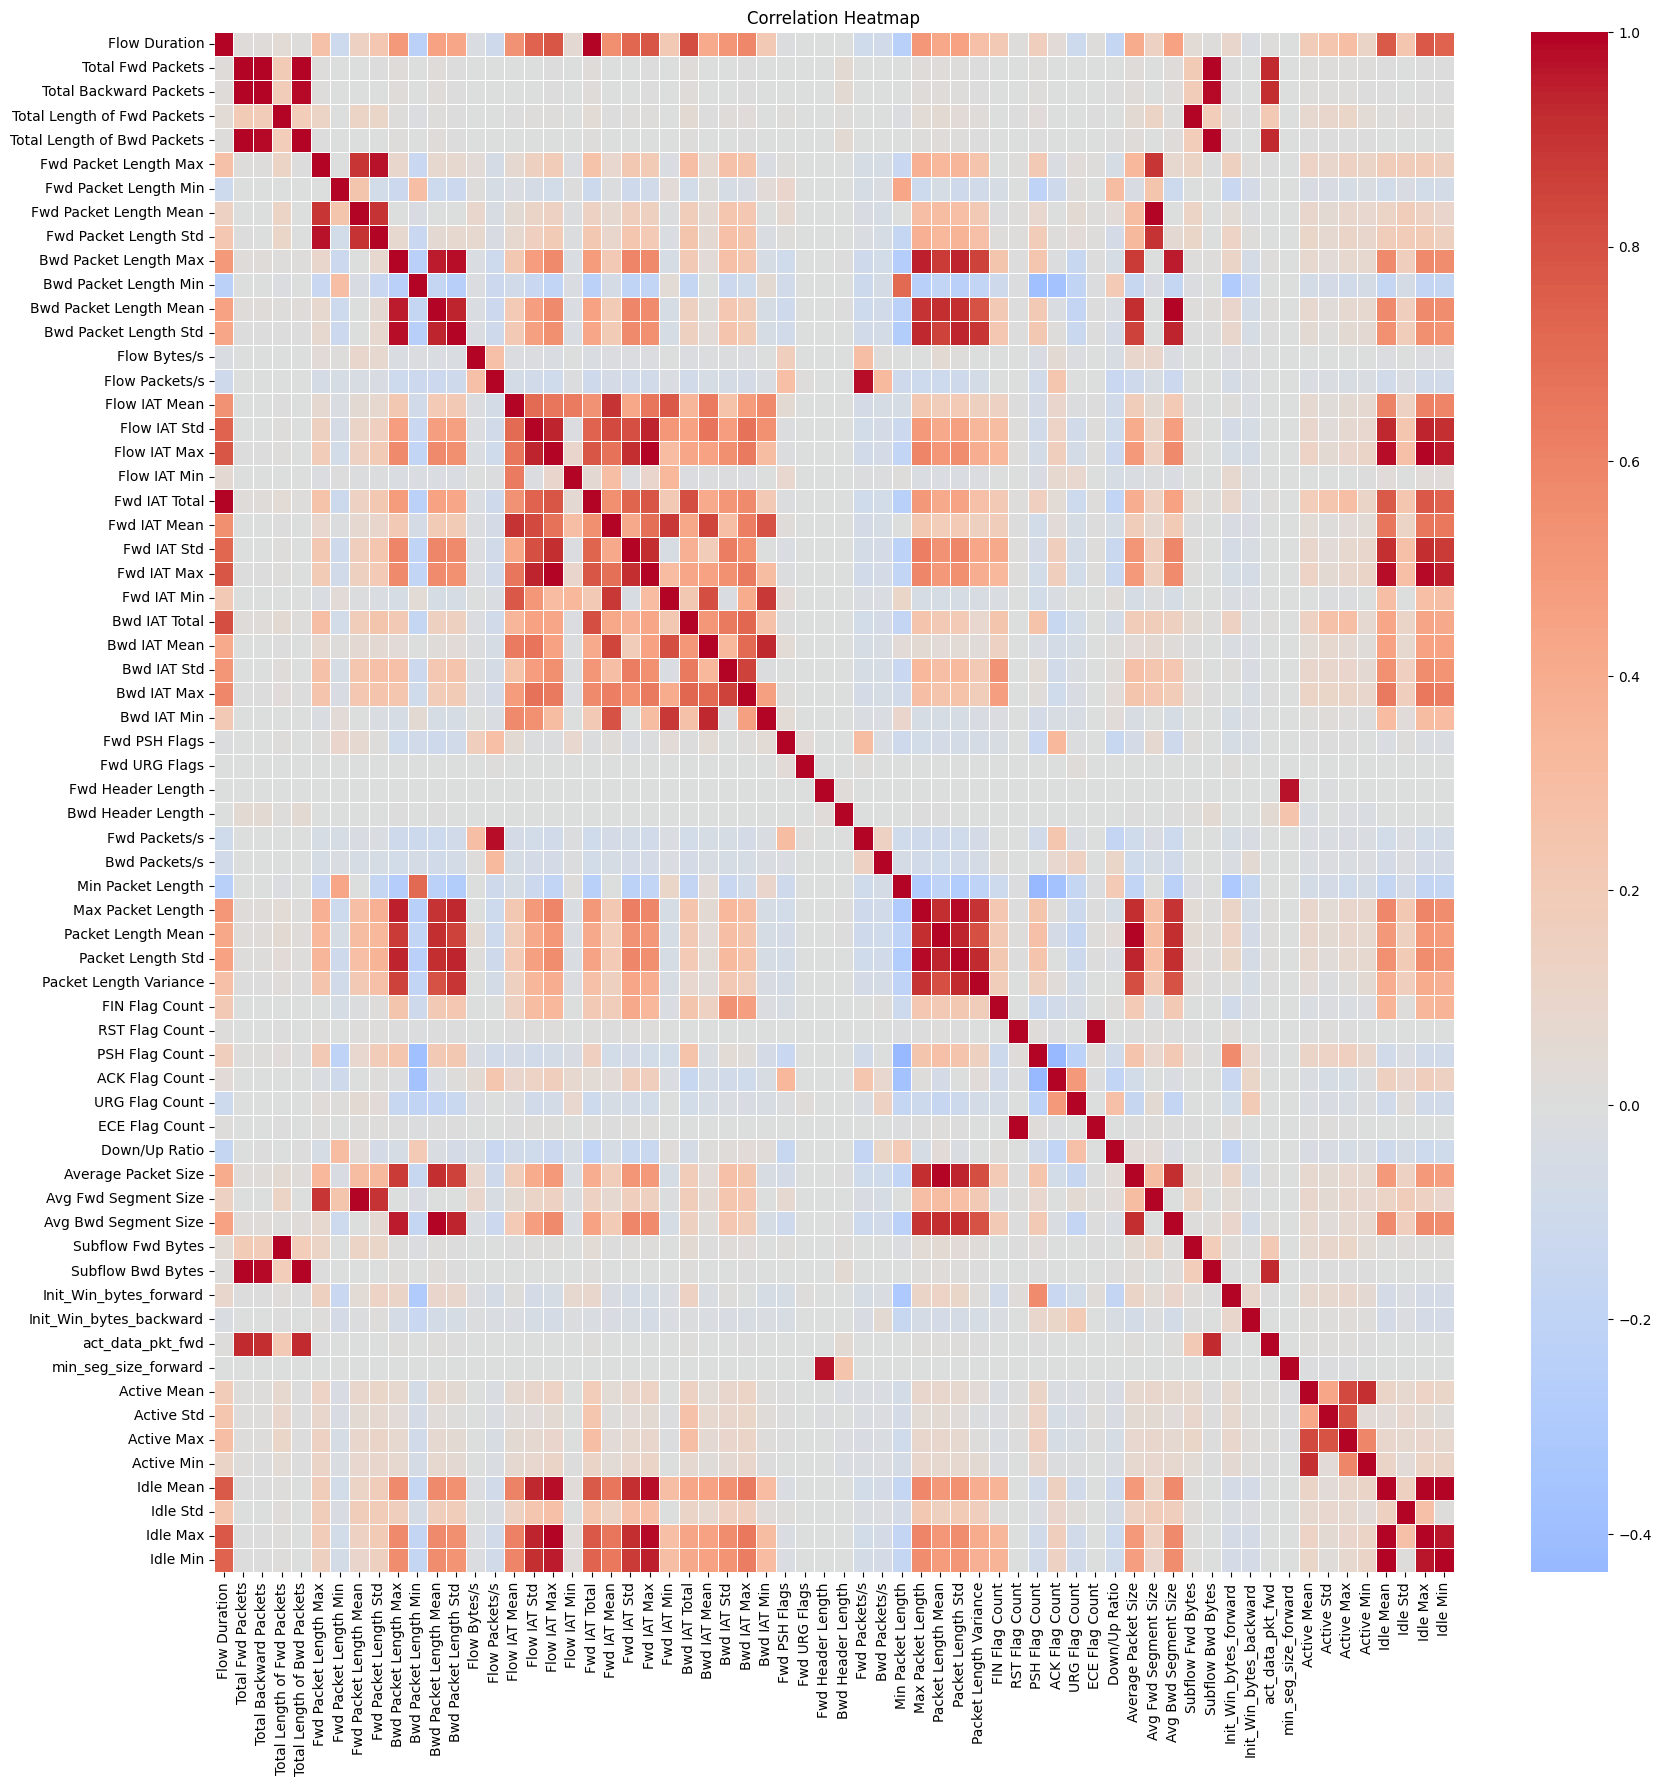

In [37]:
columns_to_drop = list(set(columns_to_drop))  # Remove duplicates from the list of columns to drop
df_dropped = df.drop(columns=columns_to_drop)

numeric_features_dropped = [col for col in df_dropped.columns if col in numeric_features]

high_corr = correlation_analysis(df_dropped[numeric_features_dropped], numeric_features_dropped, threshold=0.95)

In [38]:
high_corr_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation Coefficient']).sort_values(by='Correlation Coefficient', ascending=False)
high_corr_df

,Feature 1,Feature 2,Correlation Coefficient
13,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
9,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
7,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000
6,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
0,Flow Duration,Fwd IAT Total,0.998556
1,Total Fwd Packets,Total Backward Packets,0.998162
15,Flow IAT Max,Fwd IAT Max,0.998081
23,Packet Length Mean,Average Packet Size,0.997820
24,RST Flag Count,ECE Flag Count,0.997471
2,Total Fwd Packets,Total Length of Bwd Packets,0.993680


We have features with high correlation but we must validate if correlation constitute to redundancy. Standard computation for correlation only considers linear relationships and might not consider those with irregular-shaped relationship.

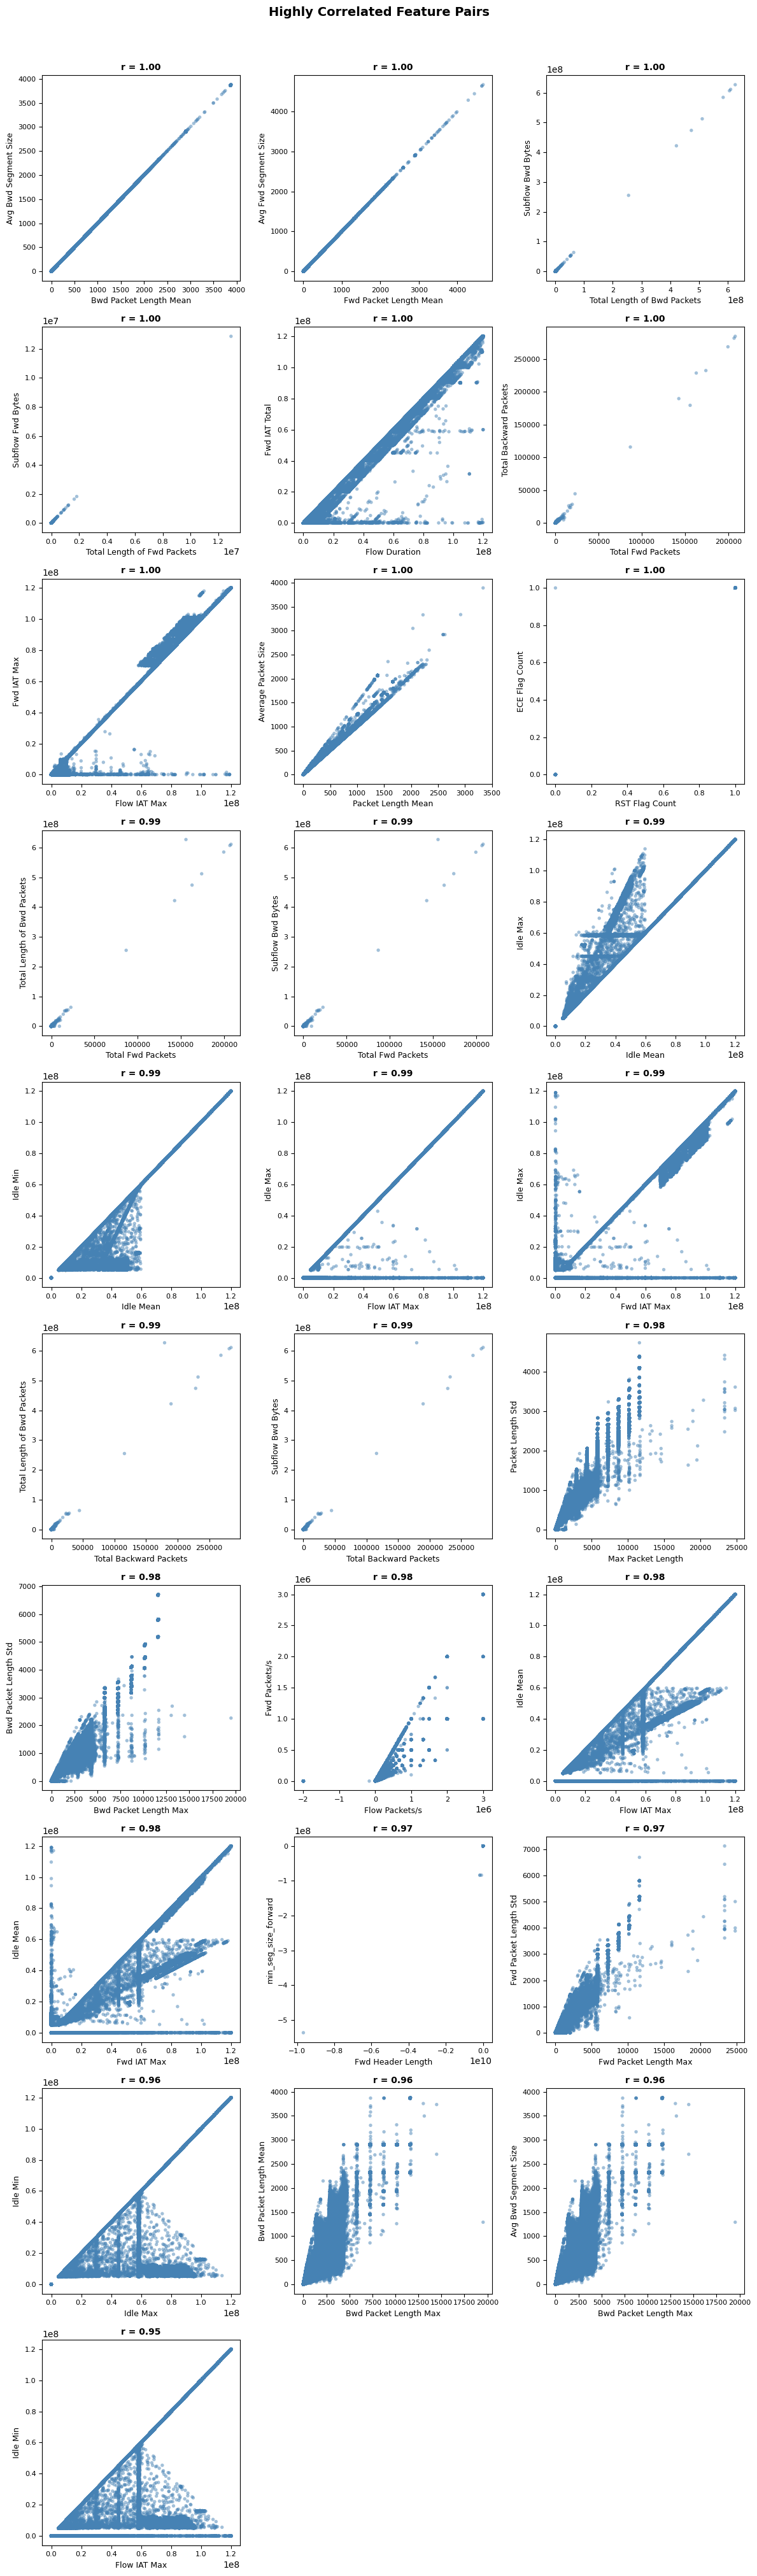

In [ ]:
def plot_correlation_scatterplots(df, high_corr_df, figsize_per_plot=(4, 4)):
    n = len(high_corr_df)
    cols = 3  # number of columns in the grid
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_plot[0], rows * figsize_per_plot[1]))
    axes = axes.flatten()  # flatten to 1D for easy indexing

    for i, (_, row) in enumerate(high_corr_df.iterrows()):
        feat1 = row['Feature 1']
        feat2 = row['Feature 2']
        corr  = row['Correlation Coefficient']

        ax = axes[i]
        ax.scatter(df[feat1], df[feat2], alpha=0.5, s=15, color='steelblue', edgecolors='none')
        ax.set_xlabel(feat1, fontsize=9)
        ax.set_ylabel(feat2, fontsize=9)
        ax.set_title(f'r = {corr:.2f}', fontsize=10, fontweight='bold')
        ax.tick_params(labelsize=8)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Highly Correlated Feature Pairs', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('correlation_scatterplots.png', dpi=150, bbox_inches='tight')
    plt.show()

# Usage
plot_correlation_scatterplots(df, high_corr_df)

The visuals have provided alot of info for our validation, but it does not help us in deciding what to drop with the correlation pairs. We could do it based on domain knowledge, but we can also pit the two based on their feature importance which would be discussed later on.

## Class Imbalance Analysis
This is to confirm whether the data will be treated for anomaly detection or classification problem. 

Data with imbalanced data produces model which is heavily biased to the group with greater distribution. 

Accuracy is the general and well understood metrics, especially for classification. But with imbalanced dataset, it is misleading because correctly predicting the majority will bring great result, drowning out results of the minority even if they were inaccurate.

Anomalies in data, which are normally rare and sparse in nature, is an example of imbalanced dataset and requires a set of performance metrics aside from accuracy

In [39]:
df['anomaly'].value_counts(normalize=True)

anomaly
0    0.823108
1    0.176892
Name: proportion, dtype: float64

## Variance Checking

## Feature Importance

Calculating scores for all features...


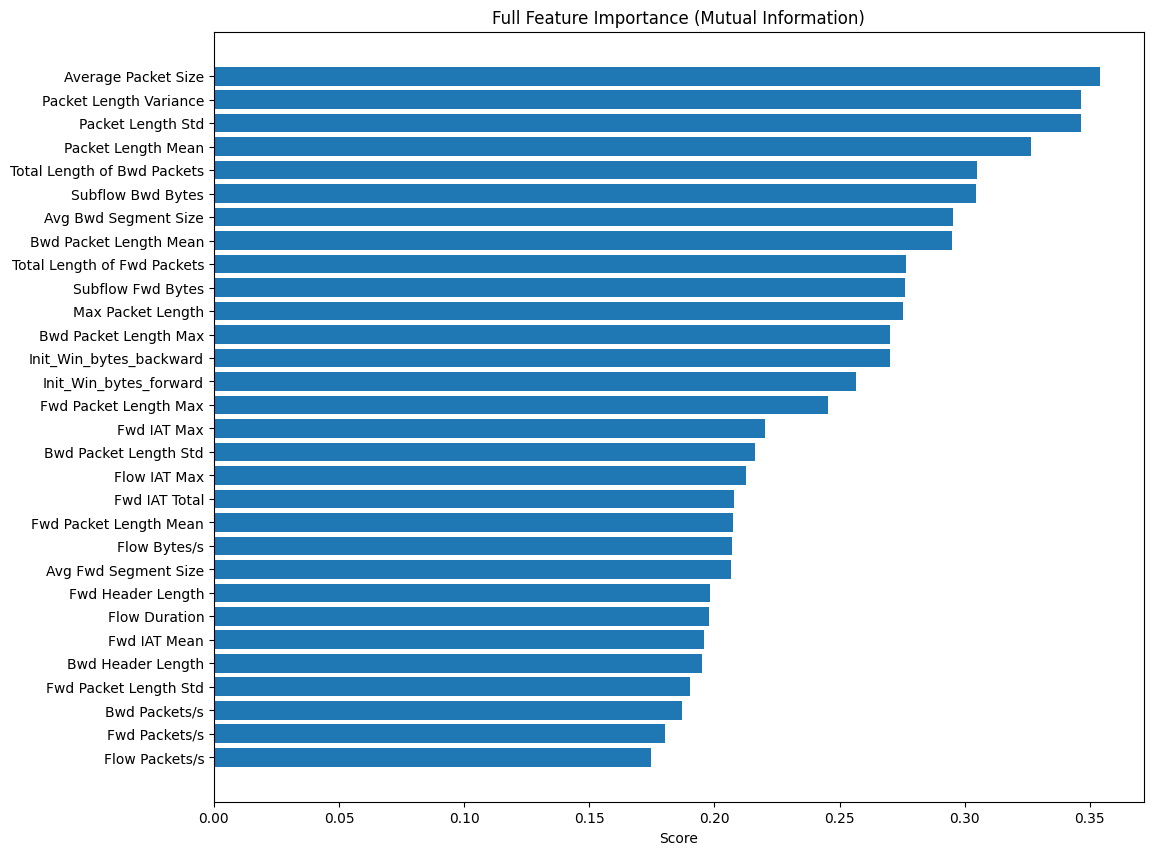

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# We also need to drop the 'Destination Port' column as it is a categorical feature with a large number of unique values, which would require extensive encoding and may not provide significant predictive power for our model.
X = df_dropped.drop(columns=['anomaly','Label','Destination Port'])
y = df_dropped['anomaly']


score_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('selector', SelectKBest(score_func=mutual_info_classif, k='all'))
])

print("Calculating scores for all features...")
score_pipeline.fit(X, y)

mi_scores = score_pipeline.named_steps['selector'].scores_

# 5. Create a DataFrame for easy viewing
feature_info = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# Quick Plot of the Top 30
plt.figure(figsize=(12, 10))
plt.barh(feature_info['Feature'].head(30), feature_info['MI_Score'].head(30))
plt.gca().invert_yaxis()
plt.title("Full Feature Importance (Mutual Information)")
plt.xlabel("Score")
plt.show()

## Correlation part 2

Going back to correlation analysis, here we've used the feature importance scores to determine which feature to drop high feature correlation pairs 

In [40]:
high_corr_df['f1_iscore'] = high_corr_df['Feature 1'].map(feature_info.set_index('Feature')['MI_Score'])
high_corr_df['f2_iscore'] = high_corr_df['Feature 2'].map(feature_info.set_index('Feature')['MI_Score'])

# We can use the mutual information scores to help decide which feature to keep from each highly correlated pair. Generally, we would keep the feature with the higher mutual information score, as it is likely to be more informative for our target variable.
high_corr_df['Feature_to_drop'] = high_corr_df.apply(
    lambda row: row['Feature 1'] if row['f1_iscore'] < row['f2_iscore'] else row['Feature 2'], axis=1
)
corr_redundant_drop = high_corr_df.loc[high_corr_df['Correlation Coefficient'] > 0.9999,'Feature_to_drop'].tolist()

columns_to_drop.extend(corr_redundant_drop)

In [41]:
high_corr_df

,Feature 1,Feature 2,Correlation Coefficient,f1_iscore,f2_iscore,Feature_to_drop
13,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,0.295085,0.295164,Bwd Packet Length Mean
9,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,0.207429,0.206717,Avg Fwd Segment Size
7,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,0.304771,0.304343,Subflow Bwd Bytes
6,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000,0.276654,0.276217,Subflow Fwd Bytes
0,Flow Duration,Fwd IAT Total,0.998556,0.197923,0.207973,Flow Duration
1,Total Fwd Packets,Total Backward Packets,0.998162,0.111530,0.129020,Total Fwd Packets
15,Flow IAT Max,Fwd IAT Max,0.998081,0.212589,0.220287,Flow IAT Max
23,Packet Length Mean,Average Packet Size,0.997820,0.326472,0.353876,Packet Length Mean
24,RST Flag Count,ECE Flag Count,0.997471,0.000599,0.000000,ECE Flag Count
2,Total Fwd Packets,Total Length of Bwd Packets,0.993680,0.111530,0.304771,Total Fwd Packets


# Feature Engineering

## PCA
PCA is a dimension reduction techniques which transforms the data to components that better represent it. Transforming our data reduces the features we need to analyze into components that better represent it. We can then analyze this if there are comparable clusters happening in our data and relate it to our known target

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [43]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
pca_data = pca.fit_transform(scaled_X)
# create a new dataframe with the pca data and the target variable
pca_df = pd.DataFrame(data=pca_data, columns=[f'pca_{i+1}' for i in range(30)])
pca_df['quality'] = df['anomaly']

Explained variance ratio: [0.23537453 0.09408798 0.07802996 0.06434131 0.0483884  0.04598523
 0.03799509 0.03516482 0.03137778 0.03118222 0.03044055 0.02821184
 0.02373376 0.01989713 0.01927824 0.01690998 0.01569985 0.01550785
 0.0153622  0.01435243 0.01420316 0.01325532 0.01147049 0.01103672
 0.0088637  0.00860315 0.00639735 0.0045763  0.00424635 0.0039718 ]


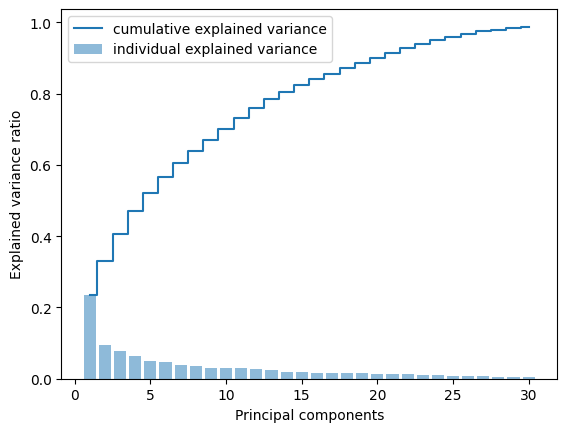

In [44]:
# Plot the explained variance ratio and the cumulative variance
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='cumulative explained variance')
plt.xlabel('Principal components')
plt.ylabel('Explained variance ratio')
plt.legend(loc='best')

In [45]:
# Identify the minimum number of components required to retain at least 90% of the total variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f'Minimum number of components to retain at least 90% variance: {n_components_90}')

Minimum number of components to retain at least 90% variance: 20


<Axes: xlabel='pca_1', ylabel='pca_2'>

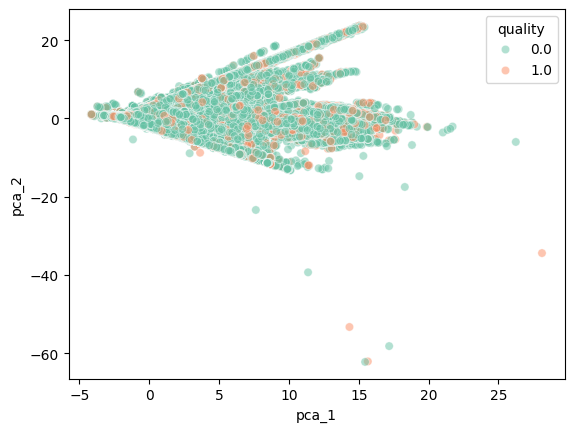

In [46]:
sns.scatterplot(data=pca_df, x='pca_1', y='pca_2', hue='quality', alpha=0.5, palette='Set2')

But with our topmost PCs, we can't infer any insights on how anomalies are formed on our data

## Domain specific features

### Bytes per packet
Average payload size per packet

- Normal traffic > consistent sizes
- Scans > tiny packets
- Exfiltration > large packets

In [47]:
# To create a new feature that represents the average bytes per packet, we can divide the 'Total Length of Fwd Packets' by the 'Total Fwd Packets'. However, to avoid division by zero, we will add a small constant (epsilon) to the denominator.
EPS = 1e-6

df['bytes_per_packet'] = (
    df['Total Length of Fwd Packets'] /
    (df['Total Fwd Packets'] + EPS)
)

### Packets per Second Normalized by Bytes

This detects burst traffic independent of volume.

High value = many small packets (scan/flood).

In [48]:
df['packet_rate_ratio'] = (
    df['Flow Packets/s'] /
    (df['Flow Bytes/s'] + EPS)
)

### Forward/Backward Packet Ratio
- Normal TCP ≈ balanced.
- DDoS / scans > one-sided traffic.

In [49]:
df['fwd_bwd_packet_ratio'] = (
    df['Total Fwd Packets'] /
    (df['Total Backward Packets'] + EPS)
)

### Direction Dominance

In [50]:
df['direction_dominance'] = (
    abs(df['Total Fwd Packets'] - df['Total Backward Packets']) /
    (df['Total Fwd Packets'] + df['Total Backward Packets'] + EPS)
)

### Packets per Flow Duration

In [51]:
df['packet_density'] = (
    (df['Total Fwd Packets'] + df['Total Backward Packets']) /
    (df['Flow Duration'] + EPS)
)

### Interarival Time Variability

In [52]:
df['iat_variability'] = (
    df['Flow IAT Std'] /
    (df['Flow IAT Mean'] + EPS)
)

### SYN Flag and ACK Response Ratio

In [53]:
df['syn_ratio'] = (
    df['SYN Flag Count'] /
    (df['Total Fwd Packets'] + EPS)
)

df['ack_ratio'] = (
    df['ACK Flag Count'] /
    (df['Total Backward Packets'] + EPS)
)

### Payload Efficiency
This detects overhead-heavy attacks

In [54]:
df['payload_efficiency'] = (
    df['Total Length of Fwd Packets'] /
    (df['Flow Duration'] + EPS)
)

## Log Transformations to Heavy Tailed Metrics

In [55]:
skew_cols = [
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow Duration'
]

for c in skew_cols:
    df[c+'_log'] = np.log1p(df[c].clip(lower=0))

## Destination Port distribution

In [59]:
# get normalized distribution of destination port
df['Destination Port Distribution'] = df['Destination Port'].map(df['Destination Port'].value_counts(normalize=True))

columns_to_drop.extend(['Destination Port'])

# Export Processed Data

In [61]:
# log added features and features to drop on preprocessing df config json based on the original features we saved earlier
added_features = [col for col in df.columns if col not in original_features and col != 'anomaly' and col != 'Label']
with open('..\config\preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

config['added_features'] = added_features
config['columns_to_drop'] = columns_to_drop

with open('..\config\preprocessing_df_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [84]:
df.to_parquet(os.path.join(dataset_folder, 'dataset_processed.parquet'), index=False)